# The Dirac equation and the prediction of antimatter

Special relativity says a free particle's energy and momentum obey $E^2=(pc)^2+(mc^2)^2$, so
$E=\pm\sqrt{(pc)^2+(mc^2)^2}$ -- there is a **negative** root. Schrodinger's equation, first order in
time but second order in space, cannot represent this symmetrically; the Klein-Gordon equation
(second order in both) restores it but brings negative probability densities. In 1928 **Dirac**
insisted on an equation **first order in both** space and time,
$$i\hbar\,\partial_t\psi=\big(c\,\boldsymbol\alpha\cdot\mathbf p+\beta mc^2\big)\psi,$$
and squaring it back to $E^2=(pc)^2+(mc^2)^2$ forces $\boldsymbol\alpha,\beta$ to **anticommute** --
they cannot be numbers, they must be $4\times4$ matrices. The price of that four-component wavefunction
is two extra solutions with negative energy, which Dirac reinterpreted as a new particle of the same
mass and opposite charge: the **positron** (antielectron), found by Anderson in 1932.

This notebook derives that chain: the two energy roots, the Clifford algebra the matrices must satisfy,
the gamma matrices in SymPy, and the Dirac Hamiltonian's $\pm E$ eigenvalues (electron and positron) in
NumPy. Self-contained: NumPy, SymPy, Pandas, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The two energy roots and the mass gap

$E^2=(pc)^2+(mc^2)^2$ has two branches: $E=+\sqrt{\cdots}$ (electron) and $E=-\sqrt{\cdots}$ (the
antiparticle branch), separated by a gap of $2mc^2$ at $p=0$. SymPy solves for both; the plot is the
relativistic dispersion relation.

In [2]:
p, mc2, pc = sp.symbols('p m_c2 pc', real=True, positive=True)
E = sp.symbols('E', real=True)
roots = sp.solve(sp.Eq(E**2, pc**2 + mc2**2), E)
print("E =", roots, "  (two branches; gap 2 m c^2 at p=0)")
assert set(roots) == {sp.sqrt(pc**2+mc2**2), -sp.sqrt(pc**2+mc2**2)}

mc2_MeV = C.M_E*C.C**2/C.E/1e6                      # electron rest energy in MeV
print(f"electron rest energy m c^2 = {mc2_MeV:.4f} MeV")
print(f"mass gap 2 m c^2 = {2*mc2_MeV:.4f} MeV  (pair-production / annihilation energy)")
assert abs(mc2_MeV - 0.511) < 1e-3

E = [-sqrt(m_c2**2 + pc**2), sqrt(m_c2**2 + pc**2)]   (two branches; gap 2 m c^2 at p=0)
electron rest energy m c^2 = 0.5110 MeV
mass gap 2 m c^2 = 1.0220 MeV  (pair-production / annihilation energy)


## Why the coefficients must be matrices (Clifford algebra)

Write $E=c\,\boldsymbol\alpha\cdot\mathbf p+\beta mc^2$ and square it. The cross terms cancel and the
squares reproduce $E^2=(pc)^2+(mc^2)^2$ **only if**
$$\alpha_i\alpha_j+\alpha_j\alpha_i=2\delta_{ij}\,\mathbb 1,\quad
\alpha_i\beta+\beta\alpha_i=0,\quad \alpha_i^2=\beta^2=\mathbb 1.$$
No four ordinary numbers anticommute like this, so $\alpha_i,\beta$ are matrices -- the smallest that
work are $4\times4$. In the Dirac representation they are built from the $2\times2$ Pauli matrices.

In [3]:
sx = sp.Matrix([[0,1],[1,0]]); sy = sp.Matrix([[0,-sp.I],[sp.I,0]]); sz = sp.Matrix([[1,0],[0,-1]])
I2, Z2, I4 = sp.eye(2), sp.zeros(2), sp.eye(4)
blk = lambda a,b,c,d: sp.Matrix(sp.BlockMatrix([[a,b],[c,d]]))
ax = blk(Z2,sx,sx,Z2); ay = blk(Z2,sy,sy,Z2); az = blk(Z2,sz,sz,Z2)   # alpha_i = [[0,sigma],[sigma,0]]
beta = blk(I2,Z2,Z2,-I2)                                              # beta = diag(I, -I)
alphas = [ax, ay, az]
anti = lambda M,Nn: M*Nn + Nn*M
for i in range(3):
    for j in range(3):
        assert anti(alphas[i], alphas[j]) == (2 if i==j else 0)*I4    # {a_i,a_j}=2 delta_ij
    assert anti(alphas[i], beta) == sp.zeros(4)                       # {a_i, beta}=0
    assert alphas[i]**2 == I4
assert beta**2 == I4
print("Clifford algebra verified: {a_i,a_j}=2 delta_ij,  {a_i,beta}=0,  a_i^2=beta^2=I")

Clifford algebra verified: {a_i,a_j}=2 delta_ij,  {a_i,beta}=0,  a_i^2=beta^2=I


## The gamma matrices and the covariant algebra

Define $\gamma^0=\beta$, $\gamma^i=\beta\alpha_i$. They satisfy the compact covariant form
$\{\gamma^\mu,\gamma^\nu\}=2g^{\mu\nu}\mathbb 1$ with the metric $g=\mathrm{diag}(1,-1,-1,-1)$ -- the
defining relation of the Dirac (Clifford) algebra, from which all of relativistic quantum mechanics
follows.

In [4]:
g0 = beta; gammas = [g0, beta*ax, beta*ay, beta*az]
metric = sp.diag(1,-1,-1,-1)
for mu in range(4):
    for nu in range(4):
        assert anti(gammas[mu], gammas[nu]) == 2*metric[mu,nu]*I4
print("{gamma^mu, gamma^nu} = 2 g^{mu nu} I  verified for all 16 pairs")

{gamma^mu, gamma^nu} = 2 g^{mu nu} I  verified for all 16 pairs


## The Dirac Hamiltonian: electron and positron energies

$H=c\,\boldsymbol\alpha\cdot\mathbf p+\beta mc^2$ is, for a fixed momentum, a $4\times4$ Hermitian
matrix. Its four eigenvalues are $\pm\sqrt{(pc)^2+(mc^2)^2}$, each **doubly degenerate** -- the two
signs are the electron and the positron, the double degeneracy is spin up/down. Diagonalizing it
numerically (units $c=m=\hbar=1$, momentum along $z$) reproduces the relativistic energies exactly.

In [5]:
anp = lambda M: np.array(M.tolist(), dtype=complex)
AX, AY, AZ, B = anp(ax), anp(ay), anp(az), anp(beta)
def dirac_H(px, py, pz, mass=1.0, c=1.0):
    return c*(AX*px + AY*py + AZ*pz) + B*mass*c**2

rows = []
for pz in (0.0, 0.5, 1.0, 2.0):
    ev = np.sort(np.linalg.eigvalsh(dirac_H(0,0,pz)))
    Erel = np.sqrt(pz**2 + 1.0)                       # sqrt((pc)^2+(mc^2)^2), c=m=1
    rows.append({"p_z": pz, "eigenvalues": np.round(ev,3).tolist(), "+-sqrt(p^2+1)": round(Erel,3)})
    assert np.allclose(ev, [-Erel,-Erel,+Erel,+Erel])  # two -E (positron), two +E (electron)
print(pd.DataFrame(rows).to_string(index=False))
print("\neigenvalues are +-sqrt((pc)^2+(mc^2)^2), each doubly degenerate (spin up/down)")

 p_z                    eigenvalues  +-sqrt(p^2+1)
 0.0         [-1.0, -1.0, 1.0, 1.0]          1.000
 0.5 [-1.118, -1.118, 1.118, 1.118]          1.118
 1.0 [-1.414, -1.414, 1.414, 1.414]          1.414
 2.0 [-2.236, -2.236, 2.236, 2.236]          2.236

eigenvalues are +-sqrt((pc)^2+(mc^2)^2), each doubly degenerate (spin up/down)


## Antimatter: reading the negative-energy branch

Dirac could not discard the negative-energy solutions (a positive-energy electron would cascade into
them). His resolution -- and the modern Feynman-Stuckelberg reading -- is that a filled negative-energy
state behaves as a **positron**: same mass $m_e$, charge $+e$, and (by CPT) an identical spectrum to the
electron. Consequences that follow directly:

- **Pair production**: a photon of energy $\ge 2m_ec^2=1.022\ \mathrm{MeV}$ can create an $e^-e^+$ pair.
- **Annihilation**: $e^-+e^+\to\gamma\gamma$, two $511\ \mathrm{keV}$ photons back-to-back (the basis of
  PET imaging).
- **Antihydrogen**: a positron bound to an antiproton has the same $-13.6/n^2\ \mathrm{eV}$ levels as
  hydrogen (`dgs/hydrogen_atom.py` flags this CPT identity).

In [6]:
E_photon_for_pair = 2*mc2_MeV
print(f"pair-production threshold (photon energy): {E_photon_for_pair:.3f} MeV")
print(f"annihilation photons: 2 x {mc2_MeV*1e3:.1f} keV, emitted back-to-back")
# a 511 keV gamma-ray wavelength (for scale): lambda = hc/E
lam_pm = C.H*C.C/(mc2_MeV*1e6*C.E)*1e12
print(f"511 keV photon wavelength = {lam_pm:.3f} pm  (a gamma ray)")
assert abs(E_photon_for_pair - 1.022) < 2e-3

pair-production threshold (photon energy): 1.022 MeV
annihilation photons: 2 x 511.0 keV, emitted back-to-back
511 keV photon wavelength = 2.426 pm  (a gamma ray)


## Plots

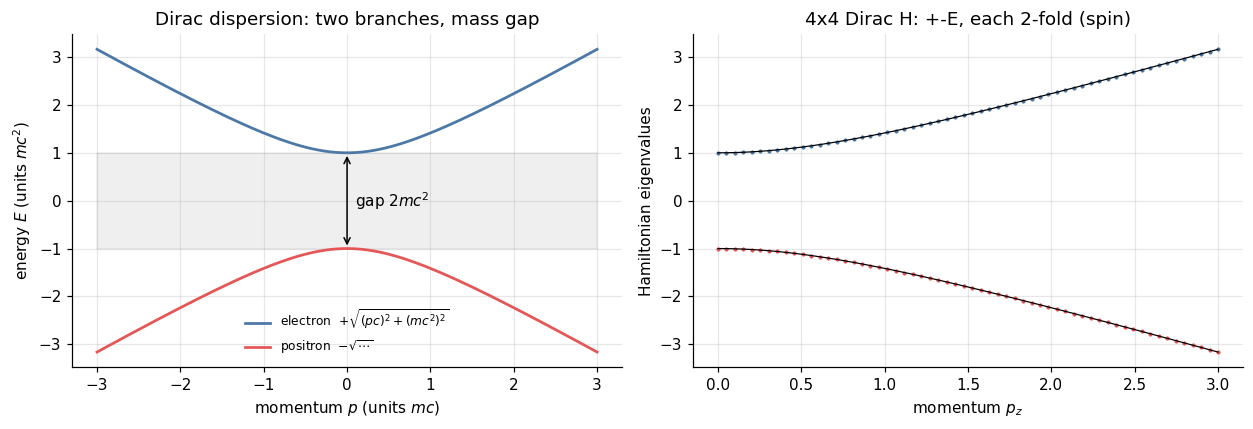

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
pp = np.linspace(-3, 3, 400)
ax[0].plot(pp, np.sqrt(pp**2+1), color="#4C78A8", label="electron  $+\\sqrt{(pc)^2+(mc^2)^2}$")
ax[0].plot(pp, -np.sqrt(pp**2+1), color="#E45756", label="positron  $-\\sqrt{\\cdots}$")
ax[0].fill_between(pp, -1, 1, color="gray", alpha=0.12)
ax[0].annotate("", xy=(0,1), xytext=(0,-1), arrowprops=dict(arrowstyle="<->"))
ax[0].text(0.1, 0, "gap $2mc^2$", va="center")
ax[0].set_xlabel("momentum $p$ (units $mc$)"); ax[0].set_ylabel("energy $E$ (units $mc^2$)")
ax[0].set_title("Dirac dispersion: two branches, mass gap"); ax[0].legend(fontsize=8)
# eigenvalue branches vs momentum from the 4x4 Hamiltonian
ps = np.linspace(0, 3, 60)
evs = np.array([np.sort(np.linalg.eigvalsh(dirac_H(0,0,p))) for p in ps])
for k in range(4):
    ax[1].plot(ps, evs[:,k], ".", color=["#E45756","#E45756","#4C78A8","#4C78A8"][k], ms=3)
ax[1].plot(ps, np.sqrt(ps**2+1), "k-", lw=0.8); ax[1].plot(ps, -np.sqrt(ps**2+1), "k-", lw=0.8)
ax[1].set_xlabel("momentum $p_z$"); ax[1].set_ylabel("Hamiltonian eigenvalues")
ax[1].set_title("4x4 Dirac H: +-E, each 2-fold (spin)")
plt.tight_layout(); plt.show()

## Summary

- Relativity's $E^2=(pc)^2+(mc^2)^2$ has a **negative-energy root**; Dirac's first-order equation keeps
  it and forces the coefficients $\alpha_i,\beta$ to obey the **Clifford algebra**
  $\{\alpha_i,\alpha_j\}=2\delta_{ij}$, $\{\alpha_i,\beta\}=0$ -- so they are $4\times4$ matrices
  (verified in SymPy, with $\{\gamma^\mu,\gamma^\nu\}=2g^{\mu\nu}$).
- The Dirac Hamiltonian's eigenvalues are $\pm\sqrt{(pc)^2+(mc^2)^2}$, doubly degenerate: **electron and
  positron, spin up and down** (verified in NumPy).
- The negative branch is **antimatter** -- the positron, $m_ec^2=0.511\ \mathrm{MeV}$, with pair
  production at $1.022\ \mathrm{MeV}$ and $511\ \mathrm{keV}$ annihilation gammas.

Subject-verb-object: relativity demands a negative root; Dirac linearizes the equation; the algebra
forces matrices; the matrices predict the positron. (Note: this is elementary-particle physics on its
own terms -- it is *not* a dependency of the classical dispersion phase-recovery pipeline, whose only
quantum input is photon shot noise.)